# Significance Evaluation (Guardrails vs No-Guard)

Notebook ini melakukan evaluasi signifikansi berbasis log per-slot:
- **Block bootstrap** untuk CI ΔHR
- **Wilcoxon signed-rank** untuk uji berpasangan per-slot
- **Miss-rate reduction** (relative)
- **Rate-matched analysis** (conditional on admission rate)

Semua analisis berasal dari file `results/<dataset>/*_{model}_*.jsonl` dan `*_summary_*_all_sizes.json`.


## 1) Import & konfigurasi
Set `MODEL_FULL` dan `MODEL_BASE` sesuai pasangan yang ingin diuji.

In [1]:
import json
import math
from pathlib import Path
import numpy as np
import pandas as pd

try:
    from scipy.stats import wilcoxon
except Exception as e:
    wilcoxon = None
    print('scipy tidak tersedia:', e)

RESULTS_ROOT = Path('results')

# pasangan model yang diuji
MODEL_FULL = 'ilnse_A2_guard_only'
MODEL_BASE = 'ilnse_A2_guard_no_guard'

DATASETS = [
    'wikipedia_september_2007',
    'wiki2018',
]

# bootstrap config
BOOT_BLOCK = 5      # panjang blok (slot)
BOOT_SAMPLES = 3000 # jumlah bootstrap
SEED = 1337


## 2) Loader log per-slot (jsonl)
Mengambil run terbaru berdasarkan file `*_summary_{model}_all_sizes.json`.

In [2]:
def _parse_json(line: str):
    return json.loads(line, parse_constant=lambda x: float('nan'))


def _latest_group_summary(dataset: str, model: str) -> Path:
    pattern = f"*_summary_{model}_all_sizes.json"
    files = sorted((RESULTS_ROOT / dataset).glob(pattern))
    if not files:
        raise FileNotFoundError(f'No summary found for {dataset}/{model}')

    def run_id(p: Path) -> int:
        try:
            return int(p.name.split('_', 1)[0])
        except Exception:
            return -1

    files = sorted(files, key=run_id)
    return files[-1]


def load_slots(dataset: str, model: str) -> pd.DataFrame:
    summary_path = _latest_group_summary(dataset, model)
    run_id = summary_path.name.split('_', 1)[0]
    with open(summary_path, 'r') as f:
        summary = json.load(f)
    cache_sizes = summary['cache_sizes']

    rows = []
    for cap in cache_sizes:
        jsonl = RESULTS_ROOT / dataset / f"{run_id}_{model}_{cap}.jsonl"
        if not jsonl.exists():
            raise FileNotFoundError(f'Missing slot log: {jsonl}')
        with open(jsonl, 'r') as f:
            for line in f:
                obj = _parse_json(line)
                obj['dataset'] = dataset
                obj['model'] = model
                obj['cache_size'] = cap
                # derived metrics
                req = obj.get('slot_cache_requests') or 0
                hits = obj.get('slot_cache_hits') or 0
                obj['slot_hr'] = (hits / req) if req else np.nan
                miss_cand = obj.get('miss_candidates') or 0
                admit_sel = obj.get('admit_selected') or 0
                obj['admit_rate'] = (admit_sel / miss_cand) if miss_cand else np.nan
                rows.append(obj)
    df = pd.DataFrame(rows)
    return df


## 3) Load data dan sanity check
Memastikan slot evaluasi tersedia dan jumlah slot sama antar model.

In [3]:
df_full = pd.concat([load_slots(ds, MODEL_FULL) for ds in DATASETS], ignore_index=True)
df_base = pd.concat([load_slots(ds, MODEL_BASE) for ds in DATASETS], ignore_index=True)

# hanya slot evaluasi
df_full = df_full[df_full['phase'] != 'warmup'].copy()
df_base = df_base[df_base['phase'] != 'warmup'].copy()

print('full rows:', len(df_full), 'base rows:', len(df_base))

# cek slot per cache size
check = df_full.groupby(['dataset','cache_size']).size().rename('n_full').to_frame()
check['n_base'] = df_base.groupby(['dataset','cache_size']).size()
check['diff'] = check['n_full'] - check['n_base']
check


full rows: 1020 base rows: 1020


n_full  n_base  diff
dataset                  cache_size                      
wiki2018                 16123           90      90     0
                         20154           90      90     0
                         40308           90      90     0
                         60463           90      90     0
                         80617           90      90     0
                         100772          90      90     0
wikipedia_september_2007 12221           80      80     0
                         15277           80      80     0
                         30554           80      80     0
                         45831           80      80     0
                         61109           80      80     0
                         76386           80      80     0

## 4) Miss-rate reduction (overall + per cache size)
Mengubah ΔHR kecil menjadi *relative miss-rate reduction*.

In [4]:
def miss_rate_reduction(df_f, df_b):
    rows = []
    for (ds, cap), g in df_f.groupby(['dataset','cache_size']):
        g2 = df_b[(df_b.dataset==ds) & (df_b.cache_size==cap)]
        merged = pd.merge(g[['slot_index','slot_hr']], g2[['slot_index','slot_hr']], on='slot_index', suffixes=('_f','_b'))
        hr_f = merged['slot_hr_f'].mean()
        hr_b = merged['slot_hr_b'].mean()
        miss_f = 1.0 - hr_f
        miss_b = 1.0 - hr_b
        rel_red = (miss_b - miss_f) / miss_b if miss_b > 0 else np.nan
        rows.append({
            'dataset': ds,
            'cache_size': cap,
            'HR_full': hr_f,
            'HR_base': hr_b,
            'miss_rate_full': miss_f,
            'miss_rate_base': miss_b,
            'rel_miss_reduction': rel_red,
        })
    return pd.DataFrame(rows)

miss_tbl = miss_rate_reduction(df_full, df_base)
miss_tbl.sort_values(['dataset','cache_size'])


,dataset,cache_size,HR_full,HR_base,miss_rate_full,miss_rate_base,rel_miss_reduction
0,wiki2018,16123,0.467579,0.459429,0.532421,0.540571,0.015078
1,wiki2018,20154,0.482764,0.473952,0.517236,0.526048,0.016751
2,wiki2018,40308,0.526067,0.519352,0.473933,0.480648,0.013971
3,wiki2018,60463,0.558828,0.549191,0.441172,0.450809,0.021378
4,wiki2018,80617,0.584650,0.573465,0.415350,0.426535,0.026223
5,wiki2018,100772,0.605161,0.588421,0.394839,0.411579,0.040672
6,wikipedia_september_2007,12221,0.636715,0.631308,0.363285,0.368692,0.014664
7,wikipedia_september_2007,15277,0.644506,0.639004,0.355494,0.360996,0.015242
8,wikipedia_september_2007,30554,0.669729,0.666639,0.330271,0.333361,0.009270
9,wikipedia_september_2007,45831,0.689253,0.683919,0.310747,0.316081,0.016875


## 5) Wilcoxon signed-rank (per-slot HR)
Uji berpasangan per-slot untuk melihat apakah ΔHR konsisten > 0.

In [5]:
def wilcoxon_table(df_f, df_b):
    rows = []
    for (ds, cap), g in df_f.groupby(['dataset','cache_size']):
        g2 = df_b[(df_b.dataset==ds) & (df_b.cache_size==cap)]
        merged = pd.merge(g[['slot_index','slot_hr']], g2[['slot_index','slot_hr']], on='slot_index', suffixes=('_f','_b'))
        diff = merged['slot_hr_f'] - merged['slot_hr_b']
        if wilcoxon is None:
            stat = p = np.nan
        else:
            try:
                stat, p = wilcoxon(diff, zero_method='wilcox', alternative='greater')
            except Exception:
                stat = p = np.nan
        rows.append({
            'dataset': ds,
            'cache_size': cap,
            'median_diff': float(np.nanmedian(diff)),
            'mean_diff': float(np.nanmean(diff)),
            'wilcoxon_stat': stat,
            'p_value': p,
        })
    return pd.DataFrame(rows)

wilcox_tbl = wilcoxon_table(df_full, df_base)
wilcox_tbl.sort_values(['dataset','cache_size'])


,dataset,cache_size,median_diff,mean_diff,wilcoxon_stat,p_value
0,wiki2018,16123,-0.000045,0.008151,2094.5,2.224384e-01
1,wiki2018,20154,0.000860,0.008812,3401.0,9.618164e-10
2,wiki2018,40308,0.002790,0.006715,3893.0,4.097152e-16
3,wiki2018,60463,0.009265,0.009637,3916.0,1.865871e-16
4,wiki2018,80617,0.012190,0.011185,3854.0,1.523304e-15
5,wiki2018,100772,0.019200,0.016740,3906.0,2.629385e-16
6,wikipedia_september_2007,12221,0.000395,0.005406,2922.0,2.970913e-12
7,wikipedia_september_2007,15277,0.000900,0.005502,3075.0,1.060504e-14
8,wikipedia_september_2007,30554,0.001825,0.003090,3078.0,9.439800e-15
9,wikipedia_september_2007,45831,0.005945,0.005334,3079.0,9.087408e-15


## 6) Block bootstrap CI (per-slot HR)
Mengestimasi CI untuk ΔHR dengan korelasi slot.

In [6]:
def block_bootstrap_diff(x, y, block=5, n_boot=3000, seed=0):
    rng = np.random.default_rng(seed)
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = len(x)
    idx = np.arange(n)
    blocks = [idx[i:i+block] for i in range(0, n, block)]
    k = int(math.ceil(n / block))
    diffs = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        sel_blocks = rng.integers(0, len(blocks), size=k)
        sample_idx = np.concatenate([blocks[j] for j in sel_blocks])[:n]
        diffs[i] = float(np.mean(x[sample_idx] - y[sample_idx]))
    return diffs


def bootstrap_table(df_f, df_b, block=5, n_boot=3000, seed=0):
    rows = []
    for (ds, cap), g in df_f.groupby(['dataset','cache_size']):
        g2 = df_b[(df_b.dataset==ds) & (df_b.cache_size==cap)]
        merged = pd.merge(g[['slot_index','slot_hr']], g2[['slot_index','slot_hr']], on='slot_index', suffixes=('_f','_b'))
        diffs = block_bootstrap_diff(merged['slot_hr_f'].values, merged['slot_hr_b'].values, block=block, n_boot=n_boot, seed=seed)
        lo, hi = np.percentile(diffs, [2.5, 97.5])
        rows.append({
            'dataset': ds,
            'cache_size': cap,
            'mean_diff': float(np.mean(diffs)),
            'ci_low': float(lo),
            'ci_high': float(hi),
        })
    return pd.DataFrame(rows)

boot_tbl = bootstrap_table(df_full, df_base, block=BOOT_BLOCK, n_boot=BOOT_SAMPLES, seed=SEED)
boot_tbl.sort_values(['dataset','cache_size'])


,dataset,cache_size,mean_diff,ci_low,ci_high
0,wiki2018,16123,0.008290,0.000764,0.017780
1,wiki2018,20154,0.008951,0.001387,0.018363
2,wiki2018,40308,0.006785,0.002765,0.012194
3,wiki2018,60463,0.009636,0.008629,0.010700
4,wiki2018,80617,0.011182,0.008417,0.013631
5,wiki2018,100772,0.016731,0.013157,0.019907
6,wikipedia_september_2007,12221,0.005523,0.000905,0.011237
7,wikipedia_september_2007,15277,0.005613,0.001295,0.010818
8,wikipedia_september_2007,30554,0.003129,0.001758,0.004900
9,wikipedia_september_2007,45831,0.005338,0.004446,0.006151


## 7) Rate-matched analysis (conditional on admission rate)
Bukan simulasi ulang, tetapi analisis kondisional: bandingkan HR pada bin admission rate yang sama.

In [7]:
def rate_matched_table(df_f, df_b, bins=5):
    rows = []
    for (ds, cap), g in df_f.groupby(['dataset','cache_size']):
        g2 = df_b[(df_b.dataset==ds) & (df_b.cache_size==cap)]
        merged = pd.merge(g[['slot_index','admit_rate','slot_hr']], g2[['slot_index','admit_rate','slot_hr']], on='slot_index', suffixes=('_f','_b'))
        valid = merged['admit_rate_f'].replace([np.inf, -np.inf], np.nan).dropna()
        if valid.empty:
            continue
        try:
            qbins = pd.qcut(valid, q=bins, duplicates='drop')
        except Exception:
            continue
        edges = qbins.cat.categories

        def assign_bin(x):
            for i, interval in enumerate(edges):
                if x > interval.left and x <= interval.right:
                    return i
            return np.nan

        merged['bin'] = merged['admit_rate_f'].apply(assign_bin)
        for b in sorted(merged['bin'].dropna().unique()):
            m = merged[merged['bin'] == b]
            rows.append({
                'dataset': ds,
                'cache_size': cap,
                'bin': int(b),
                'admit_rate_full_mean': float(m['admit_rate_f'].mean()),
                'admit_rate_base_mean': float(m['admit_rate_b'].mean()),
                'HR_full_mean': float(m['slot_hr_f'].mean()),
                'HR_base_mean': float(m['slot_hr_b'].mean()),
                'HR_diff': float(m['slot_hr_f'].mean() - m['slot_hr_b'].mean()),
                'n_slots': int(len(m)),
            })
    return pd.DataFrame(rows)

rate_tbl = rate_matched_table(df_full, df_base, bins=5)
rate_tbl.sort_values(['dataset','cache_size','bin'])


,dataset,cache_size,bin,admit_rate_full_mean,admit_rate_base_mean,HR_full_mean,HR_base_mean,HR_diff,n_slots
0,wiki2018,16123,0,0.010366,0.012813,0.464551,0.464550,0.000001,20
1,wiki2018,16123,1,0.012226,0.013213,0.471961,0.470957,0.001004,17
2,wiki2018,16123,2,0.013491,0.013048,0.439533,0.437575,0.001958,16
3,wiki2018,16123,3,0.016541,0.014296,0.484296,0.469996,0.014300,19
4,wiki2018,16123,4,0.032984,0.014103,0.487302,0.462981,0.024321,17
5,wiki2018,20154,0,0.012144,0.016099,0.467880,0.466116,0.001764,19
6,wiki2018,20154,1,0.013415,0.016883,0.498874,0.497923,0.000952,18
7,wiki2018,20154,2,0.015406,0.016781,0.479242,0.470455,0.008787,17
8,wiki2018,20154,3,0.017528,0.017882,0.481855,0.469362,0.012493,17
9,wiki2018,20154,4,0.038635,0.018173,0.486349,0.466315,0.020034,19


## 8) Ringkasan akhir (gabungkan hasil)
Tabel berikut siap dipakai untuk narasi evaluator (CI + p‑value + miss‑rate reduction).

In [8]:
summary = miss_tbl.merge(wilcox_tbl, on=['dataset','cache_size']).merge(boot_tbl, on=['dataset','cache_size'])
summary.sort_values(['dataset','cache_size'])


,dataset,cache_size,HR_full,HR_base,miss_rate_full,miss_rate_base,rel_miss_reduction,median_diff,mean_diff_x,wilcoxon_stat,p_value,mean_diff_y,ci_low,ci_high
0,wiki2018,16123,0.467579,0.459429,0.532421,0.540571,0.015078,-0.000045,0.008151,2094.5,2.224384e-01,0.008290,0.000764,0.017780
1,wiki2018,20154,0.482764,0.473952,0.517236,0.526048,0.016751,0.000860,0.008812,3401.0,9.618164e-10,0.008951,0.001387,0.018363
2,wiki2018,40308,0.526067,0.519352,0.473933,0.480648,0.013971,0.002790,0.006715,3893.0,4.097152e-16,0.006785,0.002765,0.012194
3,wiki2018,60463,0.558828,0.549191,0.441172,0.450809,0.021378,0.009265,0.009637,3916.0,1.865871e-16,0.009636,0.008629,0.010700
4,wiki2018,80617,0.584650,0.573465,0.415350,0.426535,0.026223,0.012190,0.011185,3854.0,1.523304e-15,0.011182,0.008417,0.013631
5,wiki2018,100772,0.605161,0.588421,0.394839,0.411579,0.040672,0.019200,0.016740,3906.0,2.629385e-16,0.016731,0.013157,0.019907
6,wikipedia_september_2007,12221,0.636715,0.631308,0.363285,0.368692,0.014664,0.000395,0.005406,2922.0,2.970913e-12,0.005523,0.000905,0.011237
7,wikipedia_september_2007,15277,0.644506,0.639004,0.355494,0.360996,0.015242,0.000900,0.005502,3075.0,1.060504e-14,0.005613,0.001295,0.010818
8,wikipedia_september_2007,30554,0.669729,0.666639,0.330271,0.333361,0.009270,0.001825,0.003090,3078.0,9.439800e-15,0.003129,0.001758,0.004900
9,wikipedia_september_2007,45831,0.689253,0.683919,0.310747,0.316081,0.016875,0.005945,0.005334,3079.0,9.087408e-15,0.005338,0.004446,0.006151


## 9) Plot ΔHR per cache size
Menampilkan selisih HR (Full − Base) per ukuran cache untuk tiap dataset.

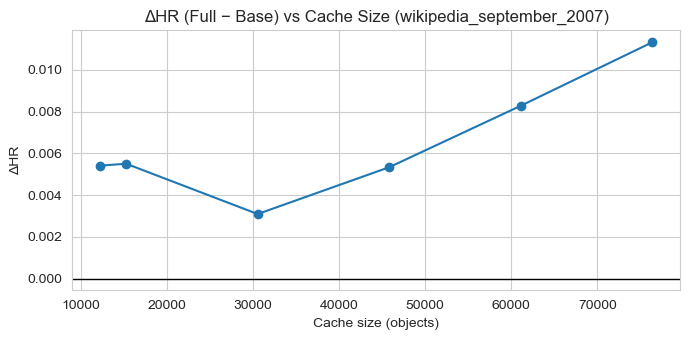

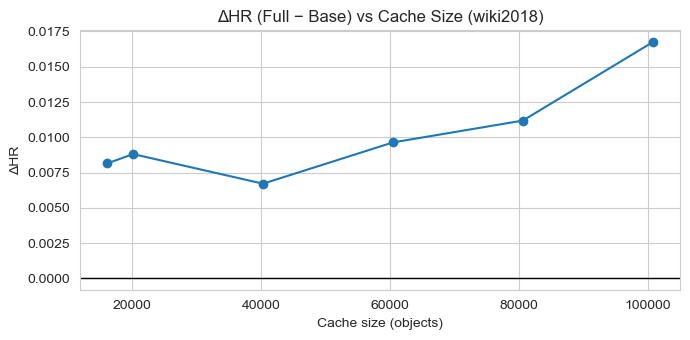

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
out_dir = Path('src/matriks/results/figures_significance')
out_dir.mkdir(parents=True, exist_ok=True)


for ds in DATASETS:
    sub = miss_tbl[miss_tbl.dataset == ds].sort_values('cache_size')
    if sub.empty:
        continue
    plt.figure(figsize=(7, 3.5))
    plt.plot(sub.cache_size, sub.HR_full - sub.HR_base, marker='o')
    plt.axhline(0.0, color='k', lw=1)
    plt.title(f"ΔHR (Full − Base) vs Cache Size ({ds})")
    plt.xlabel('Cache size (objects)')
    plt.ylabel('ΔHR')
    plt.tight_layout()
    fname = f'delta_hr_{ds}'
    plt.savefig(out_dir / f'{fname}.png', dpi=300)
    plt.savefig(out_dir / f'{fname}.pdf')
    plt.show()


## 10) Plot CI bootstrap ΔHR
Menampilkan mean ΔHR dan 95% CI (block bootstrap) per ukuran cache.

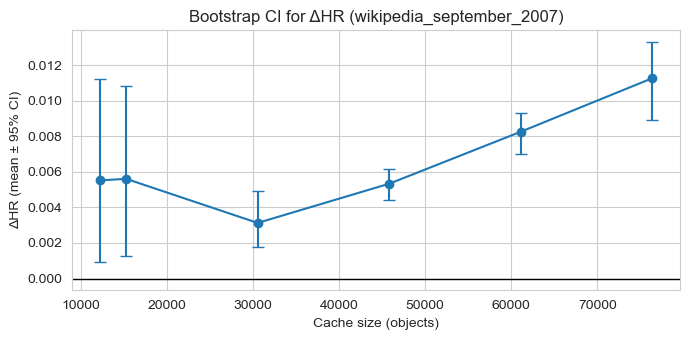

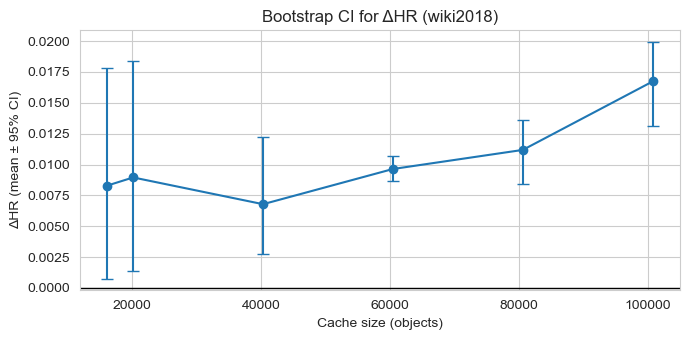

In [10]:
out_dir = Path('src/matriks/results/figures_significance')
out_dir.mkdir(parents=True, exist_ok=True)

for ds in DATASETS:
    sub = boot_tbl[boot_tbl.dataset == ds].sort_values('cache_size')
    if sub.empty:
        continue
    x = sub.cache_size.values
    y = sub.mean_diff.values
    yerr = np.vstack([y - sub.ci_low.values, sub.ci_high.values - y])

    plt.figure(figsize=(7, 3.5))
    plt.errorbar(x, y, yerr=yerr, fmt='o-', capsize=4)
    plt.axhline(0.0, color='k', lw=1)
    plt.title(f"Bootstrap CI for ΔHR ({ds})")
    plt.xlabel('Cache size (objects)')
    plt.ylabel('ΔHR (mean ± 95% CI)')
    plt.tight_layout()
    fname = f'bootstrap_ci_delta_hr_{ds}'
    plt.savefig(out_dir / f'{fname}.png', dpi=300)
    plt.savefig(out_dir / f'{fname}.pdf')
    plt.show()


## 11) Rate‑matched causal (butuh run baru)
Bagian ini akan otomatis membaca hasil *rate‑matched* jika file run sudah tersedia.


**Catatan:** ini **bukan** rate‑matched kondisional (bin admit rate). Ini butuh simulasi ulang, di mana jumlah admitted per slot pada baseline dipaksa sama dengan Full Guard.


Jika file belum ada, cell akan menampilkan instruksi nama model yang harus tersedia.

In [11]:
MODEL_RATE_MATCHED = 'ilnse_A2_guard_rate_matched'  # ganti jika nama model berbeda

try:
    df_rm = pd.concat([load_slots(ds, MODEL_RATE_MATCHED) for ds in DATASETS], ignore_index=True)
    df_rm = df_rm[df_rm['phase'] != 'warmup'].copy()

    # bandingkan Full vs Rate‑Matched
    rm_tbl = miss_rate_reduction(df_full, df_rm)
    rm_tbl.sort_values(['dataset','cache_size'])
except Exception as e:
    print('Rate‑matched data tidak ditemukan:', e)
    print('Jalankan simulasi rate‑matched dan simpan summary sebagai model:', MODEL_RATE_MATCHED)


## 12) Simpan tabel sebagai CSV
Semua tabel utama disimpan ke `src/matriks/results/tables_significance/`.

In [12]:
from pathlib import Path

out_tbl = Path('src/matriks/results/tables_significance')
out_tbl.mkdir(parents=True, exist_ok=True)

# simpan tabel jika tersedia
for name, df in [
    ('miss_rate_reduction', miss_tbl),
    ('wilcoxon', wilcox_tbl),
    ('bootstrap_ci', boot_tbl),
    ('rate_matched_bins', rate_tbl),
    # ('summary', summary),
]:
    try:
        df.to_csv(out_tbl / f'{name}.csv', index=False)
        print('saved', name)
    except Exception as e:
        print('skip', name, '->', e)


saved miss_rate_reduction
saved wilcoxon
saved bootstrap_ci
saved rate_matched_bins


## 13) Plot HR comparison (LRU, LRU‑K, IL‑Base Xu, GDBT, IL‑Guard, IL‑No‑guard)
Cell ini mencoba membaca hasil dari berbagai folder `results*` dan membangun kurva HR vs cache size.
Jika model tertentu tidak ditemukan, akan ditampilkan warning.

Dataset wiki2018: results/wiki2018
  summary files: 136
   - 001_summary_ilnse_A2_fixed_100772.json
   - 001_summary_ilnse_A2_guard_qsweep_q0.9_ema0.2_min0.5_max1.3_boost0.1_gate0.05_all_sizes.json
   - 001_summary_ilnse_A2_guard_qsweep_q0.9_ema0.2_min0.5_max1.3_boost0.1_gate0.05_80617.json
   - 001_summary_baseline_lru_100772.json
   - 001_summary_ilnse_A2_guard_qsweep_q0.9_ema0.2_min0.5_max1.3_boost0.1_gate0.05_100772.json
  latest summaries loaded: 120
  models: ['baseline_lru', 'baseline_lru-k', 'gdbt_A2', 'ilnse_A1_full', 'ilnse_A2_drift_only', 'ilnse_A2_fixed', 'ilnse_A2_full', 'ilnse_A2_guard_no_gate', 'ilnse_A2_guard_no_guard', 'ilnse_A2_guard_no_quality', 'ilnse_A2_guard_only', 'ilnse_A2_guard_precision_only', 'ilnse_A2_guard_qsweep_q0.9_ema0.1_min0.7_max1.3_boost0.1_gate0.05', 'ilnse_A2_guard_qsweep_q0.9_ema0.2_min0.5_max1.3_boost0.1_gate0.05', 'ilnse_A2_guard_qsweep_q0.9_ema0.2_min0.5_max1.5_boost0.1_gate0.05', 'ilnse_A2_guard_qsweep_q0.9_ema0.2_min0.7_max1.3_boost0.1_gate0.

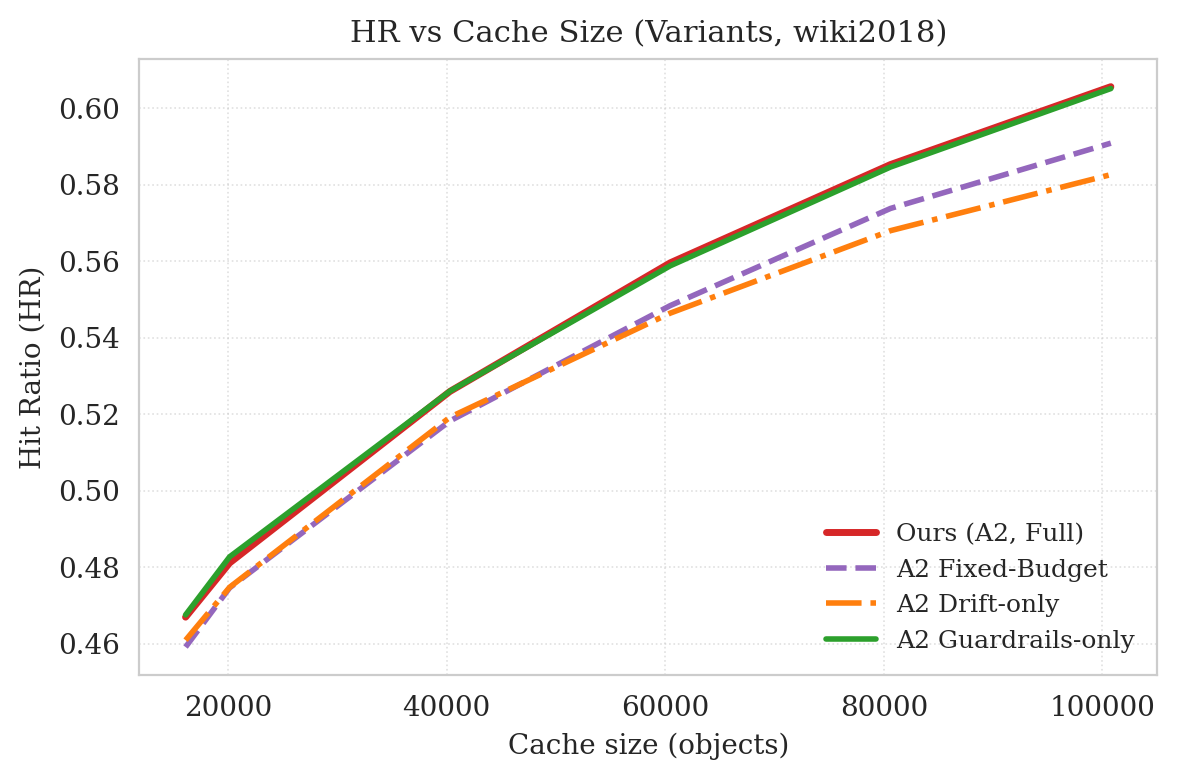

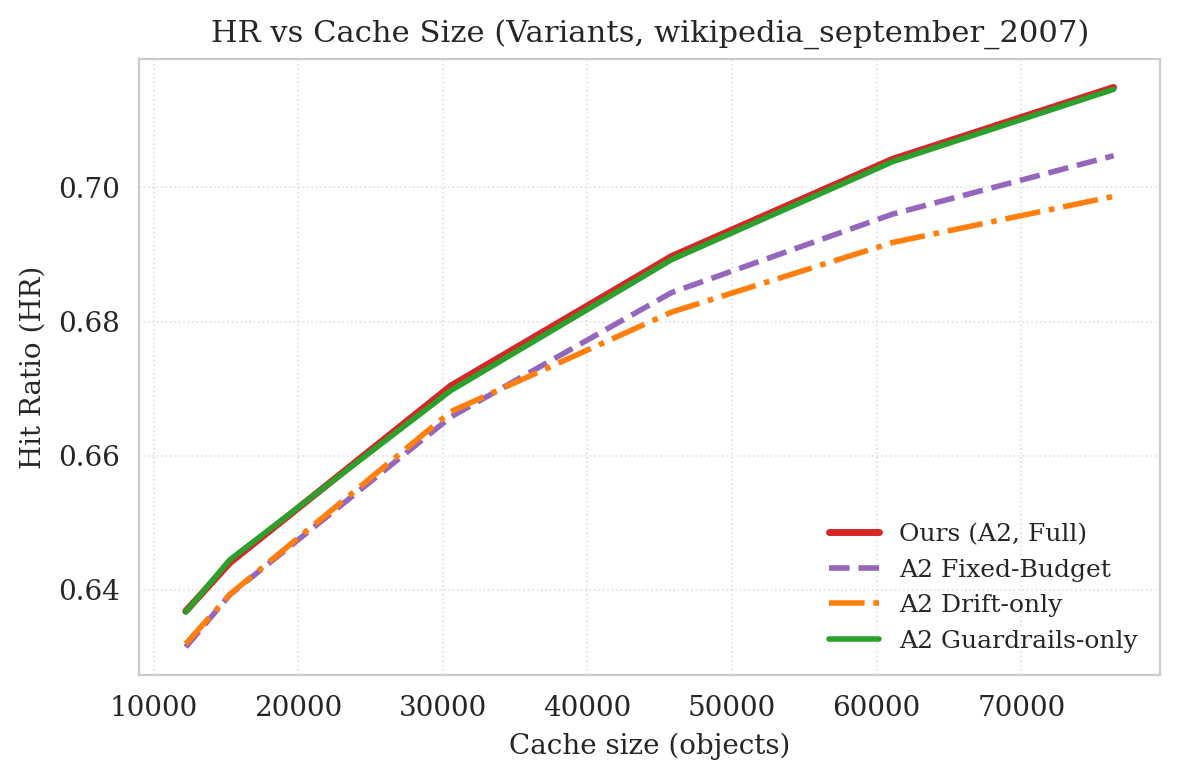

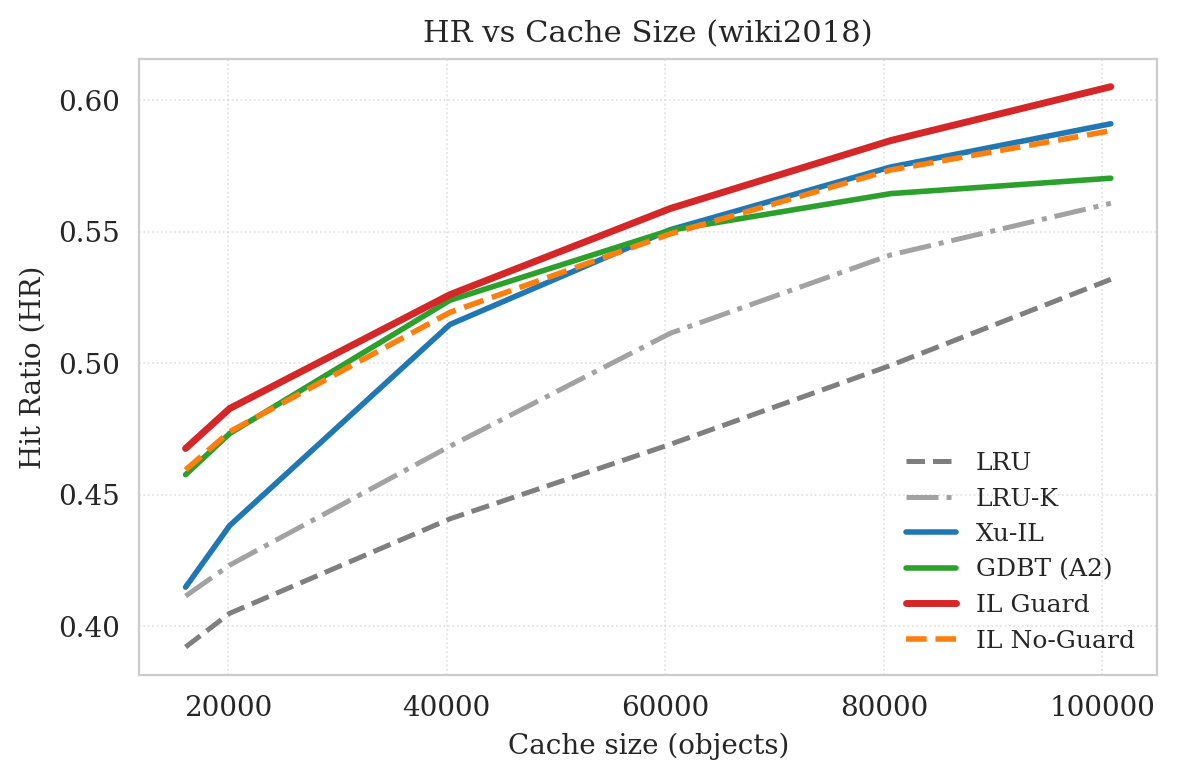

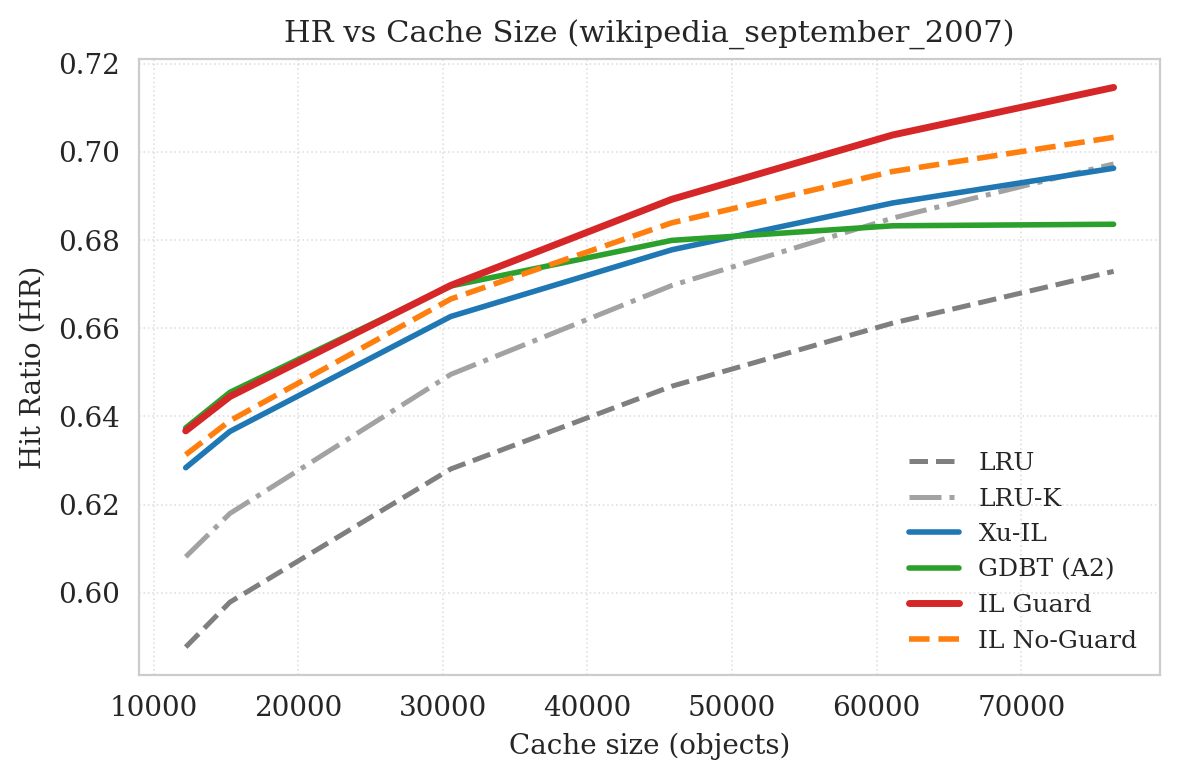

In [13]:
from __future__ import annotations
import json
import re
from pathlib import Path
import matplotlib.pyplot as plt

RESULTS_ROOT = Path('results')
OUT_DIR = Path('src/matriks/results/figures')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Select datasets and methods to compare
DATASETS = {
    'wiki2018': RESULTS_ROOT / 'wiki2018',
    'wikipedia_september_2007': RESULTS_ROOT / 'wikipedia_september_2007',
}

METHODS = {
    'baseline_lru': 'LRU',
    'baseline_lru-k': 'LRU-K',
    'ilnse_xu': 'Xu-IL',
    'gdbt_A2': 'GDBT (A2)',
    'ilnse_A2_guard_only': 'IL Guard',
    'ilnse_A2_guard_no_guard': 'IL No-Guard',
}

STYLE = {
    'baseline_lru': dict(color='#7F7F7F', lw=1.8, ls='--'),
    'baseline_lru-k': dict(color='#A2A2A2', lw=1.8, ls='-.'),
    'ilnse_xu': dict(color='#1f77b4', lw=2.0, ls='-'),
    'gdbt_A2': dict(color='#2ca02c', lw=2.0, ls='-'),
    'ilnse_A2_guard_only': dict(color='#d62728', lw=2.5, ls='-'),
    'ilnse_A2_guard_no_guard': dict(color='#ff7f0e', lw=2.0, ls='--'),
}

# Publication style
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'legend.fontsize': 9,
    'lines.linewidth': 2.0,
})

def load_latest_summaries(dataset_dir: Path):
    pat = re.compile(r'^(\d{3})_summary_(.+)_(\d+)\.json$')
    records = {}
    for p in dataset_dir.glob('*_summary_*.json'):
        if p.name.endswith('_all_sizes.json'):
            continue
        m = pat.match(p.name)
        if not m:
            continue
        run_id = int(m.group(1))
        model = m.group(2)
        cache = int(m.group(3))
        key = (model, cache)
        cur = records.get(key)
        if cur is None or run_id > cur[0]:
            records[key] = (run_id, json.loads(p.read_text()))
    return records

def build_curves(records):
    caches = sorted({c for _, c in records})
    curves = {}
    for model in METHODS:
        pts = []
        for c in caches:
            entry = records.get((model, c))
            if entry is None:
                continue
            hr = entry[1].get('hit_ratio')
            pts.append((c, hr))
        if pts:
            curves[model] = pts
    return curves

# Diagnostics: verify data availability
for ds_name, ds_dir in DATASETS.items():
    print(f'Dataset {ds_name}:', ds_dir)
    if not ds_dir.exists():
        print('  -> MISSING directory')
        continue
    files = list(ds_dir.glob('*_summary_*.json'))
    print('  summary files:', len(files))
    for f in files[:5]:
        print('   -', f.name)
    records = load_latest_summaries(ds_dir)
    print('  latest summaries loaded:', len(records))
    models = sorted({m for (m, _) in records})
    print('  models:', models)
    caches = sorted({c for (_, c) in records})
    print('  cache sizes:', caches)
    print()

# Comparison focused on ILNSE variants
VARIANT_METHODS = {
    'ilnse_A2_full': 'Ours (A2, Full)',
    'ilnse_A2_fixed': 'A2 Fixed-Budget',
    'ilnse_A2_drift_only': 'A2 Drift-only',
    'ilnse_A2_guard_only': 'A2 Guardrails-only',
    'ilnse_A0_full': 'A0 Full (gap-only)',
}

VARIANT_STYLE = {
    'ilnse_A2_full': dict(color='#d62728', lw=2.5, ls='-'),
    'ilnse_A2_fixed': dict(color='#9467bd', lw=2.0, ls='--'),
    'ilnse_A2_drift_only': dict(color='#ff7f0e', lw=2.0, ls='-.'),
    'ilnse_A2_guard_only': dict(color='#2ca02c', lw=2.0, ls='-'),
    'ilnse_A0_full': dict(color='#1f77b4', lw=2.0, ls=':'),
}

for ds_name, ds_dir in DATASETS.items():
    records = load_latest_summaries(ds_dir)
    caches = sorted({c for (_, c) in records})
    fig, ax = plt.subplots(figsize=(6.0, 4.0), dpi=200)
    for model, label in VARIANT_METHODS.items():
        pts = []
        for c in caches:
            entry = records.get((model, c))
            if entry is None:
                continue
            hr = entry[1].get('hit_ratio')
            pts.append((c, hr))
        if not pts:
            continue
        xs = [p[0] for p in pts]
        ys = [p[1] for p in pts]
        ax.plot(xs, ys, label=label, **VARIANT_STYLE.get(model, {}))

    ax.set_xlabel('Cache size (objects)')
    ax.set_ylabel('Hit Ratio (HR)')
    ax.set_title(f'HR vs Cache Size (Variants, {ds_name})')
    ax.grid(True, which='major', linestyle=':', linewidth=0.6, alpha=0.6)
    ax.set_axisbelow(True)
    ax.legend(frameon=False, ncol=1, loc='lower right')
    fig.tight_layout()
    out_path = OUT_DIR / f'hr_curve_variants_{ds_name}.pdf'
    fig.savefig(out_path)
    out_png = OUT_DIR / f'hr_curve_variants_{ds_name}.png'
    fig.savefig(out_png, dpi=300)
    print('Saved:', out_path, 'and', out_png)

for ds_name, ds_dir in DATASETS.items():
    records = load_latest_summaries(ds_dir)
    curves = build_curves(records)

    fig, ax = plt.subplots(figsize=(6.0, 4.0), dpi=200)
    for model, pts in curves.items():
        xs = [p[0] for p in pts]
        ys = [p[1] for p in pts]
        style = STYLE.get(model, {})
        ax.plot(xs, ys, label=METHODS.get(model, model), **style)

    ax.set_xlabel('Cache size (objects)')
    ax.set_ylabel('Hit Ratio (HR)')
    ax.set_title(f'HR vs Cache Size ({ds_name})')
    ax.grid(True, which='major', linestyle=':', linewidth=0.6, alpha=0.6)
    ax.set_axisbelow(True)
    ax.legend(frameon=False, ncol=1, loc='lower right')
    fig.tight_layout()
    out_path = OUT_DIR / f'hr_curve_{ds_name}.pdf'
    fig.savefig(out_path)
    out_png = OUT_DIR / f'hr_curve_{ds_name}.png'
    fig.savefig(out_png, dpi=300)
    print('Saved:', out_path, 'and', out_png)


summary_df built from results: 243


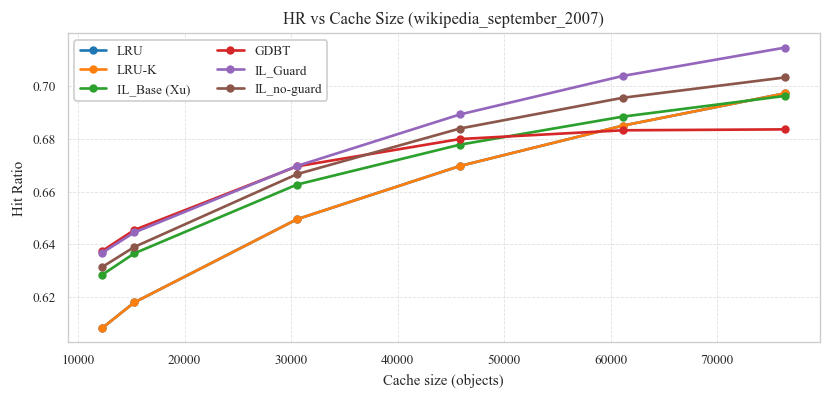

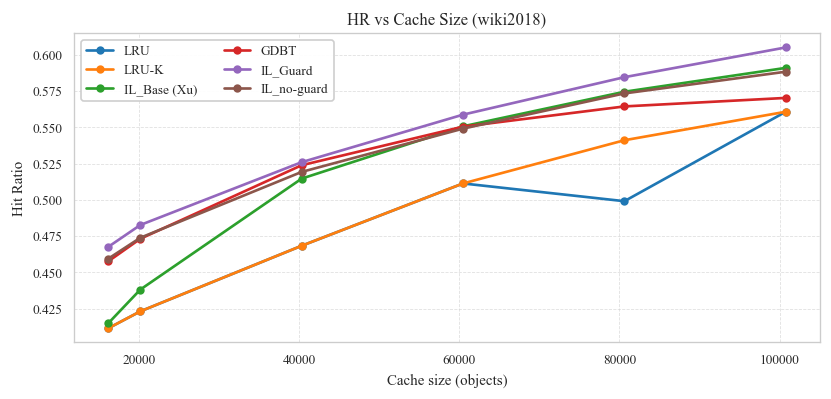

In [14]:
# ensure dataset labels are defined
if 'summary_df' not in globals():
    # build summary_df from results/<dataset> summaries
    import pandas as pd
    import re
    from pathlib import Path

    RESULTS_ROOT = Path('results')
    DATASET_DIRS = [d for d in RESULTS_ROOT.iterdir() if d.is_dir()]
    re_one = re.compile(r'^(\d{3})_summary_(.+)_(\d+)\.json$')
    rows = []
    for ds_dir in DATASET_DIRS:
        dataset = ds_dir.name
        for p in ds_dir.glob('*_summary_*.json'):
            if p.name.endswith('_all_sizes.json'):
                continue
            m = re_one.match(p.name)
            if not m:
                continue
            run_id = int(m.group(1))
            model = m.group(2)
            cache = int(m.group(3))
            try:
                payload = json.loads(p.read_text())
            except Exception:
                continue
            hr = payload.get('hit_ratio')
            if hr is None:
                continue
            rows.append({
                'dataset': dataset,
                'model': model,
                'cache_size': cache,
                'hit_ratio': float(hr),
                'run_id': run_id,
            })
    summary_df = pd.DataFrame(rows)
    print('summary_df built from results:', len(summary_df))

DATASET_LABELS = {k: [k] for k in summary_df['dataset'].unique()}

MODEL_LABELS = {
    'LRU': ['baseline_lru', 'lru'],
    'LRU-K': ['baseline_lru-k', 'lru-k', 'lruk'],
    'IL_Base (Xu)': ['ilnse_xu'],
    'GDBT': ['gdbt_A2', 'gdbt'],
    'IL_Guard': ['ilnse_A2_guard_only'],
    'IL_no-guard': ['ilnse_A2_guard_no_guard'],
}


def pick_curve(df, dataset, model_patterns):
    # find models matching any pattern
    cand = df[(df['dataset'] == dataset) & (df['model'].str.lower().apply(
        lambda x: any(p in x for p in model_patterns)
    ))]
    if cand.empty:
        return None
    # choose highest run_id per cache_size
    cand = cand.sort_values('run_id').groupby('cache_size').tail(1)
    # require at least 3 cache sizes to plot
    if cand['cache_size'].nunique() < 3:
        return None
    return cand.sort_values('cache_size')

from matplotlib import pyplot as plt
import matplotlib as mpl

# Publication-style defaults (IEEE-like)
mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 10,
    'legend.fontsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'axes.linewidth': 0.8,
    'lines.linewidth': 1.6,
    'lines.markersize': 4,
    'legend.frameon': True,
    'legend.framealpha': 0.95,
    'savefig.dpi': 300,
    'figure.dpi': 120,
})

out_dir = Path('src/matriks/results/figures_significance')
out_dir.mkdir(parents=True, exist_ok=True)

for ds in DATASET_LABELS.keys():
    plt.figure(figsize=(7.0, 3.4))
    found_any = False
    for label, patterns in MODEL_LABELS.items():
        patterns = [p.lower() for p in patterns]
        curve = pick_curve(summary_df, ds, patterns)
        if curve is None:
            print(f"[WARN] {label} not found for {ds}")
            continue
        found_any = True
        plt.plot(curve.cache_size, curve.hit_ratio, marker='o', label=label)

    if not found_any:
        plt.close()
        continue
    plt.title(f"HR vs Cache Size ({ds})")
    plt.xlabel('Cache size (objects)')
    plt.ylabel('Hit Ratio')
    plt.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.6)
    plt.legend(loc='best', ncol=2, frameon=True)
    plt.tight_layout()
    fname = f"hr_comparison_{ds}"
    plt.savefig(out_dir / f"{fname}.png", dpi=300)
    plt.savefig(out_dir / f"{fname}.pdf")
    plt.show()
